In [1]:
from datetime import datetime, timedelta
import hashlib
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 500)
from sqlalchemy import create_engine, text
import plotly.graph_objects as go

from db_manager import ConnectionManager
cnxn = ConnectionManager()

In [2]:
def count_occupancy(df, start, end, garage_id=None, by_customer_type=True):
    """
    Counts the number of records active for each minute between start and end
    Parameters:
    df (DataFrame): A DataFrame with 'EntryDate' and 'ExitDate' as datetime columns.
    by_customer_type (bool): If True, returns counts broken down by customer type
    Returns:
    Series or DataFrame: If by_customer_type=False, returns Series with minute timestamps 
                        and total counts. If True, returns DataFrame with columns for each 
                        customer type.
    """
    # Define the full minute range
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    all_minutes = pd.date_range(start=start, end=end, freq='min')
    
    # Filter on garage
    if garage_id:
        df = df[df['GarageID']==garage_id].copy()
    
    # Clip Entry and Exit to the date range
    df['EntryDate'] = df['EntryDate'].clip(lower=start, upper=end)
    df['ExitDate'] = df['ExitDate'].clip(lower=start, upper=end)
    
    # Clean data
    #df = df.dropna(subset=['EntryDate', 'ExitDate'])
    #df = df[df['EntryDate'] < df['ExitDate']]
    
    if not by_customer_type:
        # Original logic - return total counts
        counts = pd.Series(0, index=all_minutes)
        entry_counts = df['EntryDate'].dt.floor('min').value_counts()
        exit_counts = df['ExitDate'].dt.ceil('min').value_counts()
        counts = counts.add(entry_counts, fill_value=0)
        counts = counts.subtract(exit_counts, fill_value=0)
        return counts.cumsum().astype(int)
    
    else:
        # New logic - return counts by customer type
        if 'customer_type' not in df.columns:
            raise ValueError("DataFrame must have 'customer_type' column when by_customer_type=True")
        
        df = df.dropna(subset=['customer_type'])
        customer_types = sorted(df['customer_type'].unique(), reverse=True)
        
        # Initialize DataFrame with all customer types
        result_df = pd.DataFrame(0, index=all_minutes, columns=customer_types)
        
        # Process each customer type separately
        for ctype in customer_types:
            ctype_df = df[df['customer_type'] == ctype]
            
            # Apply sweep line algorithm for this customer type
            counts = pd.Series(0, index=all_minutes)
            entry_counts = ctype_df['EntryDate'].dt.floor('min').value_counts()
            exit_counts = ctype_df['ExitDate'].dt.ceil('min').value_counts()
            counts = counts.add(entry_counts, fill_value=0)
            counts = counts.subtract(exit_counts, fill_value=0)
            
            result_df[ctype] = counts.cumsum().astype(int)
        
        return result_df

def prep_summary(df, start, end, garage_id, by_customer_type=True):
    summary = count_occupancy(df, start, end, garage_id=garage_id, by_customer_type=by_customer_type)
    if 'transient' not in summary.columns:
        summary['transient'] = 0
    if 'permit' not in summary.columns:
        summary['permit'] = 0
    if 'employee' not in summary.columns:
        summary['employee'] = 0
    summary['total'] = summary['transient'] + summary['permit'] + summary['employee']
    summary['GarageID'] = garage_id #[k for k,v in garages.items() if v==garage][0]
    summary['year'] = summary.index.year
    summary['quarter'] = summary.index.quarter
    summary['month'] = summary.index.month
    summary['week'] = summary.index.isocalendar().week
    summary['day'] = summary.index.day
    summary['dayofyear'] = summary.index.dayofyear
    summary['dayofweek'] = summary.index.dayofweek
    summary['hour'] = summary.index.hour
    summary['hms'] = summary.index.strftime('%H:%M:%S')
    summary['weekday_type'] = summary['dayofweek'].apply(lambda z: 1 if z<5 else 0)
    summary['period'] = summary['hour'].apply(lambda z: 'Daytime' if 6 <= z <= 18 else 'Evening')
    summary.loc[summary['hour'].between(6, 18), 'period'] = 'Daytime'
    summary.loc[~summary['hour'].between(6, 18), 'period'] = 'Evening'
    summary.loc[summary['dayofweek']>4, 'period'] = 'Weekend'
    
    return summary.iloc[:-1]

In [3]:
def prepare():
    start_date_by_garage = pd.read_sql("SELECT GarageID, max(date) max_date FROM dw.VisitSummary GROUP BY GarageID", cnxn.get_engine('PUReporting'))
    start = datetime.strftime(start_date_by_garage['max_date'].min(), '%Y-%m-%d %H:%M:%S')
    start_prior_min = datetime.strftime(start_date_by_garage['max_date'].min()-timedelta(minutes=1), '%Y-%m-%d %H:%M:%S')
    now = datetime.now()
    end = datetime.strftime(now, '%Y-%m-%d %H:%M:00')
    end_next_min = datetime.strftime(now + timedelta(minutes=1), '%Y-%m-%d %H:%M:00')
    start_date_by_garage = {a:b for a,b in zip(start_date_by_garage['GarageID'], start_date_by_garage['max_date'])}
    utils = {
        'start_date_by_garage': start_date_by_garage,
        'start': start,
        'start_prior_min': start_prior_min,
        'end': end,
        'end_next_min': end_next_min
    }
    return utils

In [4]:
def extract(start, end):
    # Step 1: Get last entry for each garage from dw.VisitSummary
    start_prior_min = datetime.strftime(pd.to_datetime(start) - timedelta(minutes=1), '%Y-%m-%d %H:%M:%S')
    
    current_state_of_visit_summary = pd.read_sql(f"""
        --SELECT v.*
        --FROM (SELECT DISTINCT GarageID FROM dw.VisitSummary) AS g
        --CROSS APPLY (
            --SELECT TOP 1 v.*
            --FROM dw.VisitSummary AS v
            --WHERE v.GarageID = g.GarageID
            --ORDER BY v.[date] DESC
        --) AS v
        --ORDER BY GarageID

        select * from dw.VisitSummary WHERE date = '{start_prior_min}' order by GarageID
        
        """, cnxn.get_engine('PUReporting')).sort_values('GarageID').set_index('date')
    
    # Step 2: Get transactions since last time the data was run
    df = pd.read_sql(f"""
        DECLARE @Id_Parking int
        DECLARE @fromDate datetime
        DECLARE @thruDate datetime
        DECLARE @impute_duration float
        
        set @Id_Parking = 1 -- Limit to a particular garage or lot
        set @fromDate = '{start}' -- Start of date range of interest
        set @thruDate = '{end}' -- End of date range of interest
        set @impute_duration = 204.0; -- in minutes. Use this to fill in NULL entry or exit. Represents the median length of stay. Is a best guess. 
        
        -- Step 1: TicketNumbers with any entry or exit at chosen location
        WITH TicketsWithActivity AS (
                SELECT DISTINCT TicketNumber
                FROM Opms.dbo.Transactions
                WHERE 
        		  CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) BETWEEN @fromDate AND @thruDate
                  AND TransactionType in (20, 30, 31, 33, 37, 40) --31, 37?
                  AND TicketNumber NOT IN (0, 31999, 410000000, 1100000000, 220000000,  610000000, 250000000, 810000000, 710000000)
            ),
            
            -- Step 2: Latest Entry (TransactionType = 20) for each TicketNumber
            LatestEntry AS (
                SELECT t.*
                FROM TicketsWithActivity a
                CROSS APPLY (
                    SELECT TOP 1 *
                    FROM Opms.dbo.Transactions
                    WHERE TicketNumber = a.TicketNumber
                      AND TransactionType = 20
                      --AND Id_parking = @Id_Parking
                      --AND TransactionDateStamp >= DATEADD(day, -1, @fromDate) AND TransactionDateStamp < @thruDate -- can look for entries up to one week prior to fromDate but don't want an entry after thruDate
        			  AND CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) BETWEEN @fromDate AND @thruDate
                    ORDER BY CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) DESC  -- Sort DESC to be conservative and take the entry closest to the date range start
                ) t
            ),
            
            -- Step 3: Latest Exit (TransactionType = 30) for each TicketNumber
            LatestExit AS (
                SELECT t.*
                FROM TicketsWithActivity a
                CROSS APPLY (
                    SELECT TOP 1 *
                    FROM Opms.dbo.Transactions
                    WHERE TicketNumber = a.TicketNumber
                      AND TransactionType = 30
                      --AND Id_parking = @Id_Parking
                      --AND TransactionDateStamp >= @fromDate AND TransactionDateStamp < DATEADD(day, 1, @thruDate) -- can look for exits up to month after the thruDate but don't want an exit before the fromDate
        			  AND CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) BETWEEN @fromDate AND @thruDate
                    ORDER BY CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) DESC
                ) t
            ),
            
            -- Step 4: Most recent failed or manual exit (TransactionType IN 31/33/37/40)
            LatestFailedOrManual AS (
                SELECT t.*
                FROM TicketsWithActivity a
                CROSS APPLY (
                    SELECT TOP 1 *
                    FROM Opms.dbo.Transactions
                    WHERE TicketNumber = a.TicketNumber
                      AND TransactionType IN (31, 33, 37, 40)
                      --AND Id_parking = @Id_Parking
                      --AND TransactionDateStamp >= @fromDate AND TransactionDateStamp < DATEADD(day, 1, @thruDate) -- can look for exits up to week after the thruDate but don't want an exit before the fromDate
        			  AND CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) BETWEEN @fromDate AND @thruDate
                    ORDER BY CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) DESC 
                ) t
            ),
            
            -- Step 5: Bring in movements from SPM History in order to identify if parker is a permit holder
            PermitHolderMovements AS (
        		-- First gather data from permit holders who are no longer present but were at some point during the date range used
        		SELECT 
        			spm.iParkingId, pa.ParkingName, spm.lVirtualTicketNumber TicketNumber, 
                    CASE 
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.dtEntryDate
        			END dtEntryDate,
        			CASE 
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.sEntryTime
        			END sEntryTime,
        			CASE
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtExitDate AS DATE), 120) + ' ' + sExitTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.dtExitDate
        			END dtExitDate,
        			CASE
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtExitDate AS DATE), 120) + ' ' + sExitTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.sExitTime
        			END sExitTime,
        			sMediaNumber, c.sName CardHolder, g.sName GroupName, cu.sName CustomerName, cu.lId CustomerID, cAmountPaid, iEntryLocationId, iExitLocationId, eState
        	
        		FROM Opms.dbo.PresenceSpmHistory spm 
        		INNER JOIN Opms.dbo.ParkingAdmin pa On (spm.iParkingId=pa.Id_Parking)
        		LEFT JOIN ECounting.dbo.SPMCards c On (spm.sMediaNumber=c.sNumber)
        		LEFT JOIN Ecounting.dbo.SPMGroups g On (c.lGroupID=g.lId)
        		LEFT JOIN Ecounting.dbo.SPMCustomers cu On (g.lCustomerId=cu.lId)
        		WHERE
        			--spm.iParkingId = @Id_Parking
        			lVirtualTicketNumber != 0
        			AND ( -- Finds all permit visitors that came or went in the date range
                			CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) BETWEEN @fromDate AND @thruDate
                			OR CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtExitDate AS DATE), 120) + ' ' + sExitTime) BETWEEN @fromDate AND @thruDate
                		)
        			AND CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) != CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtExitDate AS DATE), 120) + ' ' + sExitTime)
        		UNION
        		-- This section brings in any present permit holders according to PresenceSPM
        		-- There is some bad data in this table. eState = 2 seems to be bad data where the entry/exit is out of whack
        		-- I also found some very old records that can't be true. It seems that when we delete a card from the system it can leave these abandoned records. Tying to current customers forces the table to drop those old/erroneous records.
        		SELECT 
        			spm.iParkingId, pa.ParkingName, spm.lVirtualTicketNumber TicketNumber, 
                    CASE 
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.dtEntryDate
        			END dtEntryDate,
        			CASE 
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.sEntryTime
        			END sEntryTime,
        			NULL dtExitDate,
        			NULL sExitTime,
        			sMediaNumber, c.sName CardHolder, g.sName GroupName, cu.sName CustomerName, cu.lId CustomerID, cAmountPaid, iEntryLocationId, iExitLocationId, eState
        	
        		FROM Opms.dbo.PresenceSpm spm
        		INNER JOIN Opms.dbo.ParkingAdmin pa On (spm.iParkingId=pa.Id_Parking)
        		LEFT JOIN ECounting.dbo.SPMCards c On (spm.sMediaNumber=c.sNumber)
        		INNER JOIN Ecounting.dbo.SPMGroups g On (c.lGroupID=g.lId)
        		INNER JOIN Ecounting.dbo.SPMCustomers cu On (g.lCustomerId=cu.lId)
        		WHERE
        			--spm.iParkingId = @Id_Parking
        			spm.lVirtualTicketNumber != 0
        			AND spm.eState != 2
                	AND ( -- Finds all permit visits that were present during any part of the date range
                		CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) BETWEEN @fromDate AND @thruDate
                	)
        	),
            
            -- Step 6: Combine results with accurate status classification. This is where we get some attributes for the records that were selected
            PenultimateStep As (
                SELECT
                    COALESCE(e.Id_Parking, x.Id_Parking, fm.Id_Parking, spm.iParkingId) Id_Parking,
        			COALESCE(pa.ParkingName, spm.ParkingName) Garage,
                    --e.TicketNumber t1, x.TicketNumber t2, fm.TicketNumber t3, spm.TicketNumber t4,
                    CASE 
        				WHEN e.TicketNumber IS NOT NULL AND (x.TicketNumber IS NOT NULL OR fm.TicketNumber IS NOT NULL) THEN 'Complete'
        				WHEN spm.TicketNumber IS NOT NULL AND spm.dtEntryDate IS NOT NULL AND spm.dtExitDate IS NOT NULL THEN 'Complete'
                        WHEN spm.TicketNumber IS NOT NULL AND spm.dtEntryDate IS NULL THEN 'Exit Only'
        				WHEN spm.TicketNumber IS NOT NULL AND spm.dtExitDate IS NULL THEN 'Entry Only - Permit Holder' -- Added this changed classification so further parts of the query wouldn't automatically impute. These are customers known to still be present
        				WHEN e.TicketNumber IS NOT NULL AND x.TicketNumber IS NULL AND fm.TicketNumber IS NULL THEN 'Entry Only'
        				WHEN (x.TicketNumber IS NOT NULL OR fm.TicketNumber IS NOT NULL) AND e.TicketNumber IS NULL THEN 'Exit Only'
        				ELSE 'Unknown'
        			END AS status,
                    CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtEntryDate AS DATE), 120) + ' ' + spm.sEntryTime) spmEntryDate, 
        			CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtExitDate AS DATE), 120) + ' ' + spm.sExitTime) spmExitDate, 
        			spm.TicketNumber As TicketNumberSPM,
        			COALESCE(e.TicketNumber, x.TicketNumber, fm.TicketNumber) AS TicketNumber,
        			COALESCE(
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtEntryDate AS DATE), 120) + ' ' + spm.sEntryTime),
                        CONVERT(DATETIME, CONVERT(VARCHAR, CAST(e.TransactionDateStamp AS DATE), 120) + ' ' + e.TransactionTimeStamp)
        			) As EntryDate,
        			e.TransactionDateStamp,
        			e.TransactionTimeStamp,
        			COALESCE(
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtExitDate AS DATE), 120) + ' ' + spm.sExitTime),
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(x.TransactionDateStamp AS DATE), 120) + ' ' + x.TransactionTimeStamp)			
        			) AS ExitDate,
        			COALESCE(
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(fm.TransactionDateStamp AS DATE), 120) + ' ' + fm.TransactionTimeStamp), 
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtExitDate AS DATE), 120) + ' ' + spm.sExitTime)
        			) AS ExitAttemptDate,
        			CASE
        				--WHEN e.TransactionDateStamp IS NOT NULL THEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(e.TransactionDateStamp AS DATE), 120) + ' ' + e.TransactionTimeStamp)
        				WHEN e.TransactionDateStamp IS NULL AND x.TransactionDate > '2000-01-01' THEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(x.TransactionDate AS DATE), 120) + ' ' + x.TransactionTime)
        				WHEN e.TransactionDateStamp IS NULL AND fm.TransactionDate > '2000-01-01' THEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(fm.TransactionDate AS DATE), 120) + ' ' + fm.TransactionTime)
        				WHEN e.TransactionDateStamp IS NULL AND x.TransactionDate = '2000-01-01' AND fm.TransactionDate = '2000-01-01' THEN DATEADD(MINUTE, -@impute_duration, CONVERT(DATETIME, CONVERT(VARCHAR, CAST(x.TransactionDateStamp AS DATE), 120) + ' ' + x.TransactionTimeStamp))
        			END As EntryDate2,
        
        			CONVERT(DATETIME, CONVERT(VARCHAR, CAST(x.TransactionDate AS DATE), 120) + ' ' + x.TransactionTime) ExitOtherTimeStamp,
        			CONVERT(DATETIME, CONVERT(VARCHAR, CAST(fm.TransactionDate AS DATE), 120) + ' ' + fm.TransactionTime) ExitAttemptOtherTimeStamp,
        
        			e.TransactionType AS TransactionType_entry,
        			x.TransactionType AS TransactionType_exit, 
        			fm.TransactionType AS TransactionType_exit_attempt,
        
        			e.TicketType EntryTicketType,
        			CASE
        				WHEN e.TicketType = -1 THEN 'lost ticket'
        				WHEN e.TicketType = -11 THEN 'manual ticket'
        				WHEN e.TicketType = 0 THEN 'KP'
        				WHEN e.TicketType = 1 THEN 'value card'
        				WHEN e.TicketType = 2 THEN 'normal DP'
        				WHEN e.TicketType = 3 THEN 'congress'
        				WHEN e.TicketType = 4 THEN 'visitor'
        				WHEN e.TicketType = 5 THEN 'fixed time per day'
        				WHEN e.TicketType = 7 THEN 'fixed number of entries'
        				WHEN e.TicketType = 8 THEN 'pool car'
        				ELSE NULL
        			END As EntryTicketTypeDesc,
        			COALESCE(x.TicketType, fm.TicketType) ExitTicketType,
        			CASE
        				WHEN x.TicketType = -1 THEN 'lost ticket'
        				WHEN x.TicketType = -11 THEN 'manual ticket'
        				WHEN x.TicketType = 0 THEN 'KP'
        				WHEN x.TicketType = 1 THEN 'value card'
        				WHEN x.TicketType = 2 THEN 'normal DP'
        				WHEN x.TicketType = 3 THEN 'congress'
        				WHEN x.TicketType = 4 THEN 'visitor'
        				WHEN x.TicketType = 5 THEN 'fixed time per day'
        				WHEN x.TicketType = 7 THEN 'fixed number of entries'
        				WHEN x.TicketType = 8 THEN 'pool car'
        				WHEN x.TicketType IS NULL THEN CASE 
        												WHEN fm.TicketType = -1 THEN 'lost ticket'
        												WHEN fm.TicketType = -11 THEN 'manual ticket'
        												WHEN fm.TicketType = 0 THEN 'KP'
        												WHEN fm.TicketType = 1 THEN 'value card'
        												WHEN fm.TicketType = 2 THEN 'normal DP'
        												WHEN fm.TicketType = 3 THEN 'congress'
        												WHEN fm.TicketType = 4 THEN 'visitor'
        												WHEN fm.TicketType = 5 THEN 'fixed time per day'
        												WHEN fm.TicketType = 7 THEN 'fixed number of entries'
        												WHEN fm.TicketType = 8 THEN 'pool car'
        												WHEN fm.TicketType IS NULL THEN NULL
        												ELSE 'unknown'
        											END
        				ELSE 'unknown'
        			END As ExitTicketTypeDesc,
        			CASE
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -1 AND COALESCE(x.Amount, fm.Amount) = 0 AND COALESCE(x.T2Amount, fm.T2Amount) = 3000 AND COALESCE(x.IdCashier, fm.IdCashier) = 0 THEN 'lost ticket: POF' -- calc entry using best guess
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -1 AND COALESCE(x.Amount, fm.Amount) != 3000 AND COALESCE(x.IdCashier, fm.IdCashier) = 0 THEN 'lost ticket: help line' -- calc entry from best guess
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -1 AND COALESCE(x.Amount, fm.Amount) = 3000 AND COALESCE(x.IdCashier, fm.IdCashier) != 0 THEN 'lost ticket: cashier' --calc entry from best guess
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -1 AND COALESCE(x.Amount, fm.Amount) != 3000 AND COALESCE(x.IdCashier, fm.IdCashier) != 0 THEN 'manual: cashier' -- calc entry from OtherTimeStamp or Amount
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = 0 AND COALESCE(x.Parking, fm.Parking) = 0 AND COALESCE(x.Amount, fm.Amount) = 3000 AND COALESCE(x.IdCashier, fm.IdCashier) = 0 THEN 'lost ticket: help line' -- calc entry from best guess
        				WHEN e.TransactionDateStamp IS NULL AND SUBSTRING(CAST(COALESCE(x.TicketNumber, fm.TicketNumber) AS VARCHAR(9)),3,1) = 9 THEN 'permit: no entry found'
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -11 AND COALESCE(x.IdCashier, fm.IdCashier) != 0 THEN 'manual: cashier' -- calc entry from OtherTimeStamp or Amount
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TIcketType) = 0 AND COALESCE(x.IdCashier, fm.IdCashier) = 0 THEN 'manual: help line' -- calc entry from OtherTimeStamp
        				WHEN e.TransactionDateStamp IS NULL AND SUBSTRING(CAST(COALESCE(x.TicketNumber, fm.TicketNumber) AS VARCHAR(9)),3,3) = '000' AND x.TransactionType = 30 AND spm.sMediaNumber IS NOT NULL THEN 'permit: manual help line exit'
        				WHEN e.TransactionDateStamp IS NULL AND spm.sMediaNumber IS NOT NULL AND COALESCE(x.Parking, fm.Parking) = 1 AND x.TransactionType = 30 THEN 'permit: manual exit'
        				WHEN e.TransactionDateStamp IS NOT NULL AND (x.TransactionDateStamp IS NOT NULL OR fm.TransactionDateStamp IS NOT NULL OR spm.dtExitDate IS NOT NULL) THEN NULL
        				WHEN spm.dtEntryDate IS NOT NULL AND spm.dtExitDate IS NULL THEN NULL -- applies to present permit holders
        				WHEN spm.dtEntryDate IS NOT NULL AND spm.dtExitDate IS NOT NULL THEN NULL
        				--WHEN e.TransactionDateStamp IS NOT NULL AND x.TransactionDateStamp IS NULL AND fm.TransactionDateStamp IS NULL AND spm.dtExitDate IS NULL THEN 'imputed' -- Do I want to have something here? Simply means status is Entry Only
        				ELSE NULL
        			END As exit_classification,
        	
        			e.Parking Parking_entry,
        			x.Parking Parking_exit, 
        			fm.Parking Parking_exit_attempt,
        	
        			COALESCE(x.Amount, fm.Amount)/100. Amount, 
        			COALESCE(x.T2Amount, fm.T2Amount)/100. T2Amount, 
        	
        			COALESCE(x.IdCashier, fm.IdCashier) IdCashier, 
        			COALESCE(x.IdShift, fm.IdShift) IdShift,	
        
        			e.T2StationAdddress EntryStation,
        			x.T2StationAdddress ExitStation, 
        			fm.T2StationAdddress ExitAttemptStation,
        			spm.sMediaNumber,
        			spm.CardHolder, 
        			spm.GroupName, 
        			spm.CustomerName, 
        			spm.CustomerID, 
        			CASE
        				WHEN spm.sMediaNumber IS NULL THEN 'transient'
        				WHEN spm.sMediaNumber IS NOT NULL AND spm.CustomerID = 929 THEN 'employee'
        				ELSE 'permit'
        			END As customer_type
        
                FROM TicketsWithActivity a
                LEFT JOIN LatestEntry e ON a.TicketNumber = e.TicketNumber
                LEFT JOIN LatestExit x ON a.TicketNumber = x.TicketNumber
                LEFT JOIN LatestFailedOrManual fm ON a.TicketNumber = fm.TicketNumber
                LEFT JOIN Opms.dbo.ParkingAdmin pa On (COALESCE(e.Id_Parking, x.Id_Parking, fm.Id_Parking)=pa.Id_Parking)
                FULL OUTER JOIN PermitHolderMovements spm On (a.TicketNumber = spm.TicketNumber AND e.TransactionDateStamp=spm.dtEntryDate AND e.TransactionTimeStamp=spm.sEntryTime
                                                        OR a.TicketNumber = spm.TicketNumber AND x.TransactionDateStamp=spm.dtExitDate AND x.TransactionTimeStamp=spm.sExitTime
                                                        OR a.TicketNumber = spm.TicketNumber AND fm.TransactionDateStamp=spm.dtExitDate AND fm.TransactionTimeStamp=spm.sExitTime
                                                        )
        		
            ),
        
        -- Final BatchData CTE that wraps everything
        BatchData AS (
            SELECT 
                --t1, t2, t3, t4,
        		CASE
        			WHEN status = 'Exit Only' AND EntryDate2 > ExitDate THEN CONVERT(VARCHAR(32), HASHBYTES('MD5', CONCAT(Id_Parking, '_', COALESCE(TicketNumber, TicketNumberSPM), '_', ISNULL(CONVERT(VARCHAR, DATEADD(MINUTE, -@impute_duration, ExitDate), 121), 'NULL'))), 2)
        			WHEN status = 'Exit Only' AND DATEDIFF(DAY, EntryDate2, ExitDate) > 8 THEN  CONVERT(VARCHAR(32), HASHBYTES('MD5', CONCAT(Id_Parking, '_', COALESCE(TicketNumber, TicketNumberSPM), '_', ISNULL(CONVERT(VARCHAR, DATEADD(MINUTE, -@impute_duration, ExitDate), 121), 'NULL'))), 2) -- Added this line. A transient vehicle should not be in the garage for more than 2 weeks. There is data with an exit only that has a EntryDate2 that was 7 years earlier.
        			ELSE CONVERT(VARCHAR(32), HASHBYTES('MD5', CONCAT(Id_Parking, '_', COALESCE(TicketNumber, TicketNumberSPM), '_', ISNULL(CONVERT(VARCHAR, COALESCE(EntryDate, EntryDate2, spmEntryDate), 121), 'NULL'))), 2)
        		END As TripDetailID,
                Id_Parking as GarageID,
                Garage,
                status,
                COALESCE(TicketNumber, TicketNumberSPM) TicketNumber, -- Ticket Number	
        		-- Calculate the final EntryDate
                CASE
                    --WHEN status = 'Exit Only' AND EntryDate2 > ExitDate THEN DATEADD(MINUTE, -@impute_duration, ExitDate)
        			--WHEN status = 'Exit Only' AND DATEDIFF(DAY, EntryDate2, ExitDate) > 8 THEN DATEADD(MINUTE, -@impute_duration, ExitDate)
                    WHEN status = 'Exit Only' THEN NULL
                    ELSE COALESCE(EntryDate, EntryDate2, spmEntryDate)
                END As EntryDate,
                EntryDate2, spmEntryDate,
                -- Calculate the final ExitDate
        		CASE 
                    WHEN status = 'Entry Only' AND EntryDate >= CONCAT(SUBSTRING(CONVERT(VARCHAR, GETDATE(), 120),1,10),' 00:00:00') THEN NULL -- if EntryDate is same day and status is Entry Only, leave exit blank
                    --WHEN status = 'Entry Only' THEN DATEADD(MINUTE, @impute_duration, EntryDate) -- otherwise impute ExitDate
                    ELSE COALESCE(ExitDate, ExitAttemptDate, spmExitDate) 
                END As ExitDate,
                CASE
                    --WHEN status = 'Exit Only' AND EntryDate2 > ExitDate THEN @impute_duration
        			--WHEN status = 'Exit Only' AND DATEDIFF(DAY, EntryDate2, ExitDate) > 8 THEN @impute_duration
                    --WHEN status = 'Entry Only' THEN @impute_duration
                    WHEN status = 'Exit Only' THEN NULL
                    WHEN status LIKE 'Entry Only%' THEN NULL
                    ELSE DATEDIFF(second, COALESCE(EntryDate, EntryDate2, spmEntryDate), COALESCE(ExitDate, ExitAttemptDate, spmExitDate))/60. 
                END As length_of_stay,
                --CASE
                    --WHEN status = 'Exit Only' AND EntryDate2 > ExitDate THEN @impute_duration
        			--WHEN status = 'Exit Only' AND DATEDIFF(DAY, EntryDate2, ExitDate) > 8 THEN @impute_duration
                    --WHEN status = 'Entry Only' THEN @impute_duration
                    --WHEN status = 'Exit Only' THEN NULL
                    --WHEN status LIKE 'Entry Only%' THEN NULL
                    --WHEN status = 'Exit Only' AND COALESCE(ExitOtherTimeStamp, ExitAttemptOtherTimeStamp) = '2000-01-01 00:00:00' THEN @impute_duration
                    --ELSE NULL
                --END AS impute_duration,
                NULL As impute_duration,
                customer_type,
                exit_classification,
                COALESCE(TransactionType_exit, TransactionType_exit_attempt) TransactionType_exit,
                EntryTicketType TicketType_entry,
                EntryTicketTypeDesc TicketTypeDesc_entry,
                ExitTicketType TicketType_exit,
                ExitTicketTypeDesc TicketTypeDesc_exit,
                Parking_entry,
                COALESCE(Parking_exit, Parking_exit_attempt) Parking_exit,
                Amount,
                T2Amount,
                IdCashier,
                IdShift,
                EntryStation,
                ExitStation, 
        		ExitAttemptStation,
                sMediaNumber As PermitNumber,
                CardHolder As PermitName,
                GroupName,
                CustomerName,
                CustomerID,
                'ZMS' As SourceSystem,
                GETDATE() As LoadDate
        
            FROM PenultimateStep
        	WHERE (TicketNumber IS NOT NULL OR TicketNumberSPM IS NOT NULL)
        )
        SELECT * FROM BatchData
        ORDER BY EntryDate""", cnxn.get_engine('opms'))
    return current_state_of_visit_summary, df

In [5]:
def garage_summary(merged, start: str, end_next_min: str, garages: dict):
    garage_summary_dict = {k:prep_summary(merged, start, end_next_min, k, True) for k,v in garages.items()}
    return garage_summary_dict

In [6]:
def build_summary_data(current_state_of_visit_summary, garage_summary_dict, garages):
    summary_data = pd.DataFrame()
    for garage_id in garages.keys():
        temp = pd.concat([current_state_of_visit_summary.query('GarageID==@garage_id'), garage_summary_dict[garage_id]])
        temp.fillna({'transient':0, 'permit':0, 'employee':0},inplace=True)
        temp['total'] = temp['transient'] + temp['permit'] + temp['employee']
        
        temp['new_transient'] = temp['transient'].iloc[0] + temp['transient']
        temp['new_permit'] = temp['permit'].iloc[0] + temp['permit']
        temp['new_employee'] = temp['employee'].iloc[0] + temp['employee']
        temp['new_total'] = temp['total'].iloc[0] + temp['total']

        summary_data = pd.concat([summary_data, temp.iloc[1:]])
    
    return summary_data

In [7]:
def transform(df, start, end_next_min, current_state_of_visit_summary, garages):
    # Step 1: Prep dataset
    df.loc[df['EntryDate']<start, 'EntryDate'] = None
    
    # Step 2: 
    garage_summary_dict = garage_summary(df, start, end_next_min, garages)

    # Step 3:
    summary_data = build_summary_data(current_state_of_visit_summary, garage_summary_dict, garages)
    
    return summary_data

In [8]:
def sql_md5_hash(Id_Parking, TicketNumber=None, EntryDate=None):
    """Revised 3/27/26 to make sure the date includes the milliseconds"""
    ticket = TicketNumber

    if EntryDate is not None:
        if isinstance(EntryDate, datetime):
            entry_str = EntryDate.strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # yyyy-mm-dd hh:mm:ss.mmm
        else:
            # If EntryDate is a string, ensure it ends with .000
            if '.' not in EntryDate:
                entry_str = EntryDate + '.000'
            else:
                entry_str = EntryDate
    else:
        entry_str = 'NULL'
    print(entry_str)
    concat_str = f"{Id_Parking}_{ticket}_{entry_str}"
    md5_hash = hashlib.md5(concat_str.encode('utf-8')).hexdigest().upper()

    return md5_hash

In [9]:
def load_summary(summary, start_date_by_garage):
    # Delete per garage so a lagging garage doesn't wipe ahead-of-schedule garages
    with cnxn.get_engine('PUReporting').begin() as conn:
        print(f"Deleting old records...")
        deleted = 0
        for garage_id, start_date in start_date_by_garage.items():
            r = conn.execute(
                text("DELETE FROM dw.VisitSummary WHERE GarageID = :gid AND date >= :last_entry"),
                {"gid": garage_id, "last_entry": start_date}
            )
            deleted += r.rowcount
        print(f"Deleted {deleted} records")

    with cnxn.get_engine('PUReporting').begin() as conn:
        start_insert_time = datetime.now()
        print(f"Inserting new records ({start_insert_time})")
        insert_result = summary[['GarageID', 'new_transient', 'new_permit', 'new_employee', 'new_total', 'year', 'quarter', 'month', 'week', 'day', 'dayofyear', 'dayofweek', 'hour', 'hms', 'weekday_type', 'period']]\
            .reset_index().rename(columns={'index':'date', 'new_transient':'transient', 'new_permit':'permit', 'new_employee':'employee', 'new_total':'total'})\
            .to_sql('VisitSummary', schema='dw', con=cnxn.get_engine('PUReporting'), if_exists='append', index=False, chunksize=1000)
        print(f"Inserted {summary.shape[0]} records")
        print("Insert completed successfully!")
        return insert_result

In [10]:
def load_summary(summary, start_date):
    # Delete records, then re-insert the updated records
    with cnxn.get_engine('PUReporting').begin() as conn:  # begin() auto-commits on success, auto-rollback on error
        print(f"Deleting old records...")
        # Try the DELETE
        delete_result = conn.execute(
            text("DELETE FROM dw.VisitSummary WHERE date >= :last_entry"),
            {"last_entry": start_date}
        )
        print(f"Deleted {delete_result.rowcount} records")
        
    with cnxn.get_engine('PUReporting').begin() as conn:
        # Then try the INSERT
        start_insert_time = datetime.now()
        print(f"Inserting new records ({start_insert_time})")    
        insert_result = summary[['GarageID', 'new_transient', 'new_permit', 'new_employee', 'new_total', 'year', 'quarter', 'month', 'week', 'day', 'dayofyear', 'dayofweek', 'hour', 'hms', 'weekday_type', 'period']]\
            .reset_index().rename(columns={'index':'date', 'new_transient':'transient', 'new_permit':'permit', 'new_employee':'employee', 'new_total':'total'})\
            .to_sql('VisitSummary', schema='dw', con=cnxn.get_engine('PUReporting'), if_exists='append', index=False, chunksize=1000)
        print(f"Inserted {summary.shape[0]} records")
        
        # Transaction auto-commits here if we reach this point
        print("Insert completed successfully!")
        end_insert_time = datetime.now()
        return insert_result

## Build Garage Dict

In [11]:
garages = pd.read_sql("SELECT Id_Parking, ParkingName garage FROM ParkingAdmin WHERE Id_Parking NOT IN (7, 9)", cnxn.get_engine('opms'))
garages = {a:b for a,b in zip(garages.Id_Parking, garages.garage)}
garages

{1: 'Overture Center',
 2: 'State St Capitol Upper',
 5: 'Lake/Frances',
 6: 'Capitol Square North',
 12: 'State St Capitol  Lower',
 18: 'Livingston',
 19: 'Wilson Street'}

## Collect Important Dates

In [248]:
utils = prepare()
utils

{'start_date_by_garage': {1: Timestamp('2026-04-30 09:08:00'),
  2: Timestamp('2026-04-30 09:08:00'),
  5: Timestamp('2026-04-30 09:08:00'),
  6: Timestamp('2026-04-30 09:08:00'),
  12: Timestamp('2026-04-30 09:08:00'),
  18: Timestamp('2026-04-30 09:08:00'),
  19: Timestamp('2026-04-30 09:08:00')},
 'start': '2026-04-30 09:08:00',
 'start_prior_min': '2026-04-30 09:07:00',
 'end': '2026-04-30 10:18:00',
 'end_next_min': '2026-04-30 10:19:00'}

In [13]:
#utils['end'] = '2025-10-28 08:12:00'
#utils['end_next_min'] = '2025-10-29 11:24:00'

In [249]:
t1 = datetime.now()

current_state_of_visit_summary, e = extract(utils['start'], utils['end'])

t = transform(e, utils['start'], utils['end_next_min'], current_state_of_visit_summary, garages)

load_date = datetime.strftime(datetime.now(), '%Y:%m:%d %H:%M:%S')
e['newLoadDate'] = datetime.now()

t2 = datetime.now()

print(f"This process lasted {round((t2 - t1).total_seconds(),1)} seconds")

This process lasted 10.3 seconds


In [250]:
num1 = t.shape[0]/7
print(num1)
assert num1.is_integer()

71.0


In [251]:
print(f"Minimum new_total must not be negative")
assert t['new_total'].min() >= 0
print('Pass')

Minimum new_total must not be negative
Pass


In [252]:
e.shape

(424, 35)

In [253]:
e['status'].value_counts()

status
Entry Only                    254
Exit Only                      81
Entry Only - Permit Holder     76
Complete                       13
Name: count, dtype: int64

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


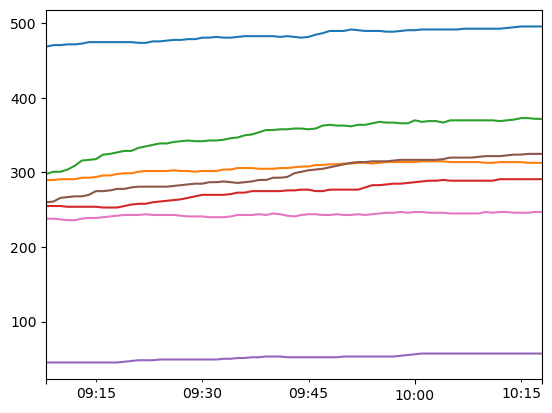

In [254]:
for gid in garages.keys():
    print(t[t['GarageID']==gid]['new_total'].plot())

In [255]:
t

,GarageID,transient,permit,employee,total,year,quarter,month,week,day,dayofyear,dayofweek,hour,hms,weekday_type,period,new_transient,new_permit,new_employee,new_total
2026-04-30 09:08:00,1,0,0,0,0,2026,2,4,18,30,120,3,9,09:08:00,1,Daytime,413,49,7,469
2026-04-30 09:09:00,1,2,0,0,2,2026,2,4,18,30,120,3,9,09:09:00,1,Daytime,415,49,7,471
2026-04-30 09:10:00,1,2,0,0,2,2026,2,4,18,30,120,3,9,09:10:00,1,Daytime,415,49,7,471
2026-04-30 09:11:00,1,2,1,0,3,2026,2,4,18,30,120,3,9,09:11:00,1,Daytime,415,50,7,472
2026-04-30 09:12:00,1,3,0,0,3,2026,2,4,18,30,120,3,9,09:12:00,1,Daytime,416,49,7,472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-30 10:14:00,19,15,-5,-2,8,2026,2,4,18,30,120,3,10,10:14:00,1,Daytime,154,85,7,246
2026-04-30 10:15:00,19,15,-5,-2,8,2026,2,4,18,30,120,3,10,10:15:00,1,Daytime,154,85,7,246
2026-04-30 10:16:00,19,15,-5,-2,8,2026,2,4,18,30,120,3,10,10:16:00,1,Daytime,154,85,7,246
2026-04-30 10:17:00,19,16,-5,-2,9,2026,2,4,18,30,120,3,10,10:17:00,1,Daytime,155,85,7,247


In [256]:
current_state_of_visit_summary[current_state_of_visit_summary['GarageID']==19]

,GarageID,transient,permit,employee,total,year,quarter,month,week,day,dayofyear,dayofweek,hour,hms,weekday_type,period
date,,,,,,,,,,,,,,,,
2026-04-30 09:07:00,19,139,90,9,238,2026,2,4,18,30,120,3,9,09:07:00,1,Daytime


# Identify Insert and Update Types for dw.VisitDetails

In [203]:
cols = ['TripDetailID', 'TripDetailID_dw', 'GarageID', 'status', 'status_dw', 'TicketNumber', 'EntryDate', 'ExitDate', 'EntryDate_dw', 'ExitDate_dw', 'length_of_stay', 'impute_duration_dw', 'Amount', 'customer_type', '_merge', 'handler']

insert_cols = ['TripDetailID', 'GarageID', 'Garage', 'status', 'TicketNumber', 'EntryDate', 'ExitDate', 'length_of_stay', 'impute_duration', 'customer_type', 'exit_classification', 'TransactionType_exit', 'TicketType_entry', 'TicketTypeDesc_entry', 
          'TicketType_exit', 'TicketTypeDesc_exit', 'Parking_entry', 'Parking_exit', 'Amount', 'T2Amount', 'IdCashier', 'IdShift', 'EntryStation', 'ExitStation', 'ExitAttemptStation', 'PermitNumber', 'PermitName', 'GroupName',
          'CustomerName', 'CustomerID', 'SourceSystem', 'LoadDate']

In [204]:
dw_in_garage = pd.read_sql(f"""
    SELECT 
        *
    FROM dw.VisitDetails
    WHERE
        TicketNumber IN ({",".join([str(x) for x in e.TicketNumber.tolist()])})
        --TripDetailID IN ('{"','".join([str(x) for x in e.TripDetailID.tolist()])}')
        --ExitDate IS NULL
    """, cnxn.get_engine('PUReporting'))
dw_in_garage.shape

(11, 33)

In [205]:
merged = e.merge(dw_in_garage, on='TicketNumber', how='left', indicator=True, suffixes=[None,'_dw'])
merged['handler'] = None

In [206]:
merged._merge.value_counts()

_merge
left_only     111
both           11
right_only      0
Name: count, dtype: int64

In [207]:
pd.pivot_table(merged, index='status', columns='status_dw', values='TripDetailID', aggfunc='count')

status_dw,Entry Only,Entry Only - Permit Holder
status,,
Exit Only,9,2


In [208]:
# Complete and Complete
mask = (merged['status']=='Complete') & (merged['status_dw']=='Complete')
merged.loc[mask, 'handler'] = 'Ignore 1'
ignore_1 = merged[mask].copy()
ignore_1.shape

(0, 69)

In [209]:
# Complete in dw, Exit Only in new data
mask = (merged['status_dw']=='Complete') & (merged['status']=='Exit Only')
# If ExitDates are the same, ignore
merged.loc[mask & (merged['ExitDate']==merged['ExitDate_dw']), 'handler'] = 'Ignore 2'
ignore_2 = merged.loc[mask & (merged['ExitDate']==merged['ExitDate_dw'])]
# If ExitDate are different, then it may need to be imputed if the TicketNumber is weird. Probably a manual exit. This is something we need to look into. 
# If ExitDate are different, and the TicketNumber is normal, then it could be due to timing when data was run. In one case, I saw a 40 being used as the exit indicator which occurred a couple minutes before the data was run. And later, 
#     a 30 occurred a few minutes after the data was run. In this situation, we would want to update the dw record with better Exit information. For this case, could look at TransactionType_exit_dw, if not 30, then you know this is one of those.
merged.loc[mask & (merged['ExitDate']!=merged['ExitDate_dw']), 'handler'] = 'Update 1'
update_1 = merged[merged['handler']=='Update 1']
update_1[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [210]:
ignore_2[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [211]:
# Update 2
# dw status is Entry Only, new data shows it complete now
# Not sure how this would happen. Maybe if there was manual changes by staff occurring. Or maybe a timing thing due to rounding
mask = (merged['status_dw']=='Entry Only') & (merged['status']=='Complete')
merged.loc[mask, 'handler'] = 'Update 2'
update_2 = merged.loc[mask]
update_2[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [212]:
# Update 3
# dw status is Entry Only - Permit Holder, new data shows a complete visit now
# Not sure how this would happen. Maybe if there was manual changes by staff occurring. 
mask = (merged['status_dw']=='Entry Only - Permit Holder') & (merged['status']=='Complete')
merged.loc[mask, 'handler'] = 'Update 3'
update_3 = merged.loc[mask]
update_3[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [213]:
# Update 4
# dw status is Entry Only, new data is olso Entry Only
# At some point these need to be closed with imputation
mask = (merged['status_dw']=='Entry Only') & (merged['status']=='Entry Only')
merged.loc[mask, 'handler'] = 'Update 4'
update_4 = merged.loc[mask]
update_4[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [214]:
# Update 5
# dw status is Entry Only, new data is olso Entry Only
# At some point these need to be closed with imputation <-- I'm not sure that's correct. 810444130 was a permit entry from that morning. Everything looks normal, I think this is a rounding issue and can be ignored.
mask = (merged['status_dw']=='Entry Only - Permit Holder') & (merged['status']=='Entry Only - Permit Holder')
merged.loc[mask, 'handler'] = 'Update 5'
update_5 = merged.loc[mask]
update_5[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [215]:
# Update 6
# dw status is Entry Only - Permit Holder, new data is olso Exit Only
mask = (merged['status_dw']=='Entry Only') & (merged['status']=='Exit Only')
merged.loc[mask, 'handler'] = 'Update 6'
update_6 = merged.loc[mask]
update_6[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler
0,6CC5ACEF74C987819EAFD9BBED974122,EBDB7CB8BB20A206DC99A6E97F632420,18,Exit Only,Entry Only,810449950,NaT,2026-04-30 08:59:09,2026-04-29 15:09:30,None,None,None,0.00,transient,both,Update 6
1,215F36A5ED844A2CA2A42E4E59BC30B4,38B95FE42640DFA031E69254061EC4B6,5,Exit Only,Entry Only,421064919,NaT,2026-04-30 08:54:07,2026-04-30 08:22:13,None,None,None,1.80,transient,both,Update 6
2,C8D41C961B1DD3A351A0F872CD850B93,39299C78123CD06B631ABBDD5D7627C0,2,Exit Only,Entry Only,241090778,NaT,2026-04-30 09:01:07,2026-04-30 00:49:16,None,None,None,12.75,transient,both,Update 6
3,93998EE1B4921490DCCC15B59DDB83D4,C236867D0558E487F8A19BCDE3174E9F,19,Exit Only,Entry Only,710541013,NaT,2026-04-30 09:00:55,2026-04-29 14:09:23,None,None,None,0.00,transient,both,Update 6
6,622F910E4E79E5EDE08E90792A06B85C,D3D557C3F51E12FDAD32A20F705E790F,6,Exit Only,Entry Only,610994704,NaT,2026-04-30 09:00:29,2026-04-29 18:01:01,None,None,None,14.00,transient,both,Update 6
7,EF5C3E66653EB32796EC4E17D64D0B92,D51E10ED56945B0414B5FE4496873FAD,19,Exit Only,Entry Only,710541271,NaT,2026-04-30 09:05:03,2026-04-30 06:58:35,None,None,None,0.00,transient,both,Update 6
8,A9B2D7A63F8F115694471A4C8A1A326A,AE9C53261E16B681E7A0310E84F14266,6,Exit Only,Entry Only,630062571,NaT,2026-04-30 08:55:36,2026-04-30 06:32:41,None,None,None,3.75,transient,both,Update 6
9,161C1F7E46654042A032D3277ED78502,EA38D684C119D0CAB372BD17E9F00B5C,2,Exit Only,Entry Only,221048248,NaT,2026-04-30 09:07:34,2026-04-30 08:26:10,None,None,None,1.50,transient,both,Update 6
10,FE18C05E6C01D2A49DBAE5A1CE694305,AFF9F8B9AE198916A87B5F366D3EE0F0,12,Exit Only,Entry Only,250308141,NaT,2026-04-30 08:56:38,2026-04-30 08:53:09,None,None,None,0.00,transient,both,Update 6


In [216]:
# Update 7
# dw status is Entry Only - Permit Holder, new data is olso Exit Only
# At some point these need to be closed with imputation
mask = (merged['status_dw']=='Entry Only - Permit Holder') & (merged['status']=='Exit Only')
merged.loc[mask, 'handler'] = 'Update 7'
update_7 = merged.loc[mask]
update_7[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler
4,D12664CF425D502EAFD718A8D638C59A,F09B71DD4173CE10B1E0E778975DA900,19,Exit Only,Entry Only - Permit Holder,710541179,NaT,2026-04-30 08:55:46,2026-04-29 18:27:16,None,None,None,0.0,permit,both,Update 7
5,23CB6921EF881EE1B7A1541BE5AC3900,46A82480B0AAD8A96CFD5F4CD0DDF0C3,6,Exit Only,Entry Only - Permit Holder,620292731,NaT,2026-04-30 09:01:12,2026-04-29 23:39:25,None,None,None,0.0,permit,both,Update 7


In [217]:
update_7.query("TicketNumber==410918680")

,TripDetailID,GarageID,Garage,status,TicketNumber,EntryDate,EntryDate2,spmEntryDate,ExitDate,length_of_stay,impute_duration,customer_type,exit_classification,TransactionType_exit,TicketType_entry,TicketTypeDesc_entry,TicketType_exit,TicketTypeDesc_exit,Parking_entry,Parking_exit,Amount,T2Amount,IdCashier,IdShift,EntryStation,ExitStation,ExitAttemptStation,PermitNumber,PermitName,GroupName,CustomerName,CustomerID,SourceSystem,LoadDate,newLoadDate,TripDetailID_dw,GarageID_dw,Garage_dw,status_dw,EntryDate_dw,ExitDate_dw,length_of_stay_dw,impute_duration_dw,customer_type_dw,exit_classification_dw,TransactionType_exit_dw,TicketType_entry_dw,TicketTypeDesc_entry_dw,TicketType_exit_dw,TicketTypeDesc_exit_dw,Parking_entry_dw,Parking_exit_dw,Amount_dw,T2Amount_dw,IdCashier_dw,IdShift_dw,EntryStation_dw,ExitStation_dw,PermitNumber_dw,PermitName_dw,GroupName_dw,CustomerName_dw,CustomerID_dw,SourceSystem_dw,LoadDate_dw,ExitAttemptStation_dw,UpdateDate,_merge,handler


In [218]:
# Update 8
# Both see an Exit Only, which shouldn't occur too often
# Could be a conflict due to manuals or lost tickets. 
mask = (merged['status_dw']=='Exit Only') & (merged['status']=='Exit Only') & (merged['ExitDate_dw']==merged['ExitDate'])
merged.loc[mask, 'handler'] = 'Update 8'
update_8 = merged.loc[mask].copy()
update_8[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [219]:
# Insert 1
# Both see an Exit Only, which shouldn't occur too often
# Could be a conflict due to manuals or lost tickets. 
mask = (merged['status_dw']=='Exit Only') & (merged['status']=='Exit Only') & (merged['ExitDate_dw']!=merged['ExitDate'])
merged.loc[mask, 'handler'] = 'Insert 1'
insert_1 = merged.loc[mask].drop_duplicates('TripDetailID').copy()
if insert_1.shape[0] > 0:
    # Set EntryDate based on chosen imputation time of 204 minutes, set length_of_stay and impute_duration
    insert_1['EntryDate'] = insert_1['ExitDate'].apply(lambda x: x - timedelta(minutes=204))
    insert_1['length_of_stay'] = 204
    insert_1['impute_duration'] = 204
    # Because there is now a chosen EntryDate, must reset the TripDetailID
    insert_1['TripDetailID'] = insert_1.apply(lambda row: sql_md5_hash(row['GarageID'], row['TicketNumber'], row['EntryDate']), axis=1)

insert_1[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [220]:
# Insert 2
# Completed visits where there is no record in the dw
mask = (merged['status_dw'].isna()) & (merged['status']=='Complete')
merged.loc[mask, 'handler'] = 'Insert 2'
insert_2 = merged.loc[mask].copy()
insert_2[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [221]:
# Insert 3
# Entry came after last data run with no indication of an exit. Presumably they're still in the garage at time of the data pull. 
mask = (merged['status_dw'].isna()) & (merged['status']=='Entry Only')
merged.loc[mask, 'handler'] = 'Insert 3'
insert_3 = merged.loc[mask].copy()
insert_3[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler
11,22BBFD79D73BFDD86915DE8B1E4F3CFB,NaN,2,Entry Only,NaN,241090833,2026-04-30 08:54:01,NaT,NaT,NaN,None,NaN,NaN,transient,left_only,Insert 3
13,3F1FD5DAA1F61F145A56CCFEE34BF8DA,NaN,19,Entry Only,NaN,730379205,2026-04-30 08:54:10,NaT,NaT,NaN,None,NaN,NaN,transient,left_only,Insert 3
14,36C98DA52BF0AF849CB2384E92467EEE,NaN,2,Entry Only,NaN,221048260,2026-04-30 08:54:11,NaT,NaT,NaN,None,NaN,NaN,transient,left_only,Insert 3
15,477D6B546D625BA81597B4FC0F83EE62,NaN,6,Entry Only,NaN,610994902,2026-04-30 08:54:41,NaT,NaT,NaN,None,NaN,NaN,transient,left_only,Insert 3
17,3C4D1FC19DB5BC9CF82ED817BFC5D735,NaN,19,Entry Only,NaN,720024489,2026-04-30 08:54:52,NaT,NaT,NaN,None,NaN,NaN,transient,left_only,Insert 3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,3035FE44B64682F369AC4AB5473AF481,NaN,19,Entry Only,NaN,730379211,2026-04-30 09:06:30,NaT,NaT,NaN,None,NaN,NaN,transient,left_only,Insert 3
116,D9D995FAC44344E68B408C1E42A1D4D0,NaN,6,Entry Only,NaN,620292772,2026-04-30 09:07:05,NaT,NaT,NaN,None,NaN,NaN,transient,left_only,Insert 3
118,5822DAACB15965CEF5A6A02C9F712932,NaN,2,Entry Only,NaN,241090837,2026-04-30 09:07:09,NaT,NaT,NaN,None,NaN,NaN,transient,left_only,Insert 3
119,37318C3B15DAF95A831C03D63595114B,NaN,6,Entry Only,NaN,610994916,2026-04-30 09:07:21,NaT,NaT,NaN,None,NaN,NaN,transient,left_only,Insert 3


In [222]:
# Insert 4
# Same as Insert 3 but this is a permit holder
mask = (merged['status_dw'].isna()) & (merged['status']=='Entry Only - Permit Holder')
merged.loc[mask, 'handler'] = 'Insert 4'
insert_4 = merged.loc[mask].copy()
insert_4[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler
12,B644C12CFE7E911C4906C573BF6A651F,NaN,1,Entry Only - Permit Holder,NaN,130055027,2026-04-30 08:54:08,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4
16,519AF370B933041976BFC0180A902A7B,NaN,18,Entry Only - Permit Holder,NaN,820195112,2026-04-30 08:54:45,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4
21,2E457AD130A18E71D19FE11D8BFD491B,NaN,6,Entry Only - Permit Holder,NaN,610994903,2026-04-30 08:55:06,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4
22,0BCBE853E2829E5612274BFF78F8E72B,NaN,1,Entry Only - Permit Holder,NaN,130055028,2026-04-30 08:55:11,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4
24,219D027CDA468729A5E83D6B7E38B871,NaN,6,Entry Only - Permit Holder,NaN,610994904,2026-04-30 08:55:15,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4
25,F65DB3C7A1CE8D31914FA0E1189FC68D,NaN,6,Entry Only - Permit Holder,NaN,620292769,2026-04-30 08:55:16,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4
26,8B8DE7FD7812F9BD9CADBCD42F6B3A7F,NaN,19,Entry Only - Permit Holder,NaN,710541335,2026-04-30 08:56:07,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4
40,3E04DA382F2AD7927C19783ED967B591,NaN,2,Entry Only - Permit Holder,NaN,221048262,2026-04-30 08:58:04,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4
43,05233F78706AB5C5FF36DEA8902E29D1,NaN,19,Entry Only - Permit Holder,NaN,730379208,2026-04-30 08:58:14,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4
46,2C898C7A1697239910288890F17B706E,NaN,1,Entry Only - Permit Holder,NaN,110114279,2026-04-30 08:58:44,NaT,NaT,NaN,None,NaN,NaN,permit,left_only,Insert 4


In [223]:
# Insert 5
# 
mask = (merged['status_dw'].isna()) & (merged['status']=='Exit Only')
merged.loc[mask, 'handler'] = 'Insert 5'
insert_5 = merged.loc[mask].copy()
if insert_5.shape[0] > 0:
    # Set EntryDate based on chosen imputation time of 204 minutes, set length_of_stay and impute_duration
    insert_5['EntryDate'] = insert_5['ExitDate'].apply(lambda x: x - timedelta(minutes=204))
    insert_5['length_of_stay'] = 204
    insert_5['impute_duration'] = 204
    # Because there is now a chosen EntryDate, must reset the TripDetailID
    insert_5['TripDetailID'] = insert_5.apply(lambda row: sql_md5_hash(row['GarageID'], row['TicketNumber'], row['EntryDate']), axis=1)

insert_5[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [224]:
# Insert 6
# The entry in dw is for an Exit Only but it matches a new visit which is complete. Likely a pretty rare event.
# Assuming different exit dates, I expect to see a weird number indicating a manual update. Possibly a lost ticket. 
# If so, ignore the dw entry, leave it as is, and enter a new record
mask = (merged['status_dw']=='Exit Only') & (merged['status']=='Complete')
merged.loc[mask & (merged['ExitDate']!=merged['ExitDate_dw']), 'handler'] = 'Ignore 6' # Ignore 6
#insert_6 = merged[mask].copy()
insert_6 = merged.loc[mask & (merged['ExitDate']!=merged['ExitDate_dw'])].drop_duplicates(['TicketNumber', 'GarageID', 'EntryDate']).copy()
insert_6[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [225]:
# Insert 7 & Ignore 7
# Situation where a very common TicketNumber matches numerous times (first time I saw it, it was 110000000 and matched on 88 visits in the dw). None of the matches are updates since they were all in the past.
# There is 1 legit new entry to insert
# status = 'Entry Only - Permit Holder'
# status_dw = 'Complete'
mask = (merged['status_dw']=='Complete') & (merged['status']=='Entry Only - Permit Holder')
merged.loc[mask & (merged['EntryDate_dw']!=merged['EntryDate']), 'handler'] = 'Ignore 7'
insert_7 = merged[mask].copy()
merged.loc[(merged.handler.isna()) & (merged['TicketNumber'].isin(insert_7['TicketNumber'].tolist())), 'handler'] = 'Ignore 7'

insert_7 = insert_7.drop_duplicates(['TicketNumber', 'GarageID', 'EntryDate'])
insert_7[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [226]:
# Insert 8 & Ignore 8
# Situation where a very common TicketNumber matches numerous times (first time I saw it, it was 3020 and matched on 88 visits in the dw). None of the matches are updates since they were all in the past.
# There is 1 legit new entry to insert
# status = 'Entry Only'
# status_dw = 'Complete'
mask = (merged['status_dw']=='Complete') & (merged['status']=='Entry Only')
merged.loc[mask & (merged['EntryDate_dw']!=merged['EntryDate']), 'handler'] = 'Ignore 8'
insert_8 = merged[mask].copy()
merged.loc[(merged.handler.isna()) & (merged['TicketNumber'].isin(insert_8['TicketNumber'].tolist())), 'handler'] = 'Ignore 8'

insert_8 = insert_8.drop_duplicates(['TicketNumber', 'GarageID', 'EntryDate'])
insert_8[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [247]:
# UPDATE TYPE 8
# Situation where there is no new data connecting to an existing dw entry, but it's been X days and it's time to manually close it with imputed data 
# Essentially, this could be the entry portion of a lost ticket situation. After some amount of time, we have to assume they're not in the garage anymore. 

update_8 = pd.read_sql("""
    SELECT 
        *,
        DATEADD(minute, 204, EntryDate) As ExitDate_new,
        204 As length_of_stay_new,
        --DATEDIFF(minute, DATEADD(minute, -204, ExitDate), ExitDate) As los_new,
        204 As impute_duration_new,
        GETDATE() As UpdateDate
    FROM dw.VisitDetails
    WHERE
        status = 'Entry Only'
        AND ExitDate IS NULL
        AND customer_type = 'transient'
        AND EntryDate <= DATEADD(day, -2, GETDATE()) -- Rethink the number of days.
        
    """, cnxn.get_engine('PUReporting'))
update_8.shape

(0, 37)

In [228]:
update_8

,TripDetailID,GarageID,Garage,status,TicketNumber,EntryDate,ExitDate,length_of_stay,impute_duration,customer_type,exit_classification,TransactionType_exit,TicketType_entry,TicketTypeDesc_entry,TicketType_exit,TicketTypeDesc_exit,Parking_entry,Parking_exit,Amount,T2Amount,IdCashier,IdShift,EntryStation,ExitStation,PermitNumber,PermitName,GroupName,CustomerName,CustomerID,SourceSystem,LoadDate,ExitAttemptStation,UpdateDate,ExitDate_new,length_of_stay_new,impute_duration_new,UpdateDate


In [229]:
# Update 9 
# Situation where there is an Exit Only status entry in dw and the EntryDate IS NULL. Need to wait at least 24 hours to do this. 

update_9 = pd.read_sql("""
    SELECT 
        *,
        CONVERT(VARCHAR(32), HASHBYTES('MD5', CONCAT(GarageID, '_', TicketNumber, '_', ISNULL(CONVERT(VARCHAR, DATEADD(minute, -204, ExitDate), 121), 'NULL'))), 2) TripDetailID_new,
        DATEADD(minute, -204, ExitDate) EntryDate_new,
        204 As length_of_stay_new,
        --DATEDIFF(minute, DATEADD(minute, -204, ExitDate), ExitDate) As los_new,
        204 As imput_duration_new,
        GETDATE() As UpdateDate
    FROM dw.VisitDetails
    WHERE
        status = 'Exit Only'
        AND EntryDate IS NULL
        AND customer_type = 'transient'
        AND ExitDate <= DATEADD(day, -1, GETDATE()) -- Rethink the number of days.
    ORDER BY ExitDate desc
    """, cnxn.get_engine('PUReporting'))
print(update_9.shape)

(0, 38)


In [230]:
merged.handler.value_counts().sort_index()

handler
Insert 3    76
Insert 4    35
Update 6     9
Update 7     2
Name: count, dtype: int64

In [231]:
assert int(merged.handler.isna().sum()) == 0
print("Assertion passes. Every record in the merged dataframe is accounted for")

Assertion passes. Every record in the merged dataframe is accounted for


In [232]:
merged[merged.handler.isna()][cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,ExitDate_dw,length_of_stay,impute_duration_dw,Amount,customer_type,_merge,handler


In [233]:
merged.shape

(122, 69)

In [234]:
# Update 1
if update_1.shape[0] > 0:
    with cnxn.get_engine('PUReporting').begin() as conn:
        for i, rec in update_1.iterrows():
            stmt = text("""
                    UPDATE dw.VisitDetails 
                    SET 
                        status = 'Complete',
                        ExitDate = :ExitDate,
                        length_of_stay = DATEDIFF(second, EntryDate, :ExitDate)/60.,
                        impute_duration = NULL,
                        exit_classification = NULL,
                        TransactionType_exit = :TransactionType_exit,
                        TicketType_exit = :TicketType_exit,
                        TicketTypeDesc_exit = :TicketTypeDesc_exit,
                        Parking_exit = :Parking_exit,
                        Amount = :Amount,
                        T2Amount = :T2Amount,
                        IdCashier = :IdCashier,
                        IdShift = :IdShift,
                        ExitStation = :ExitStation,
                        ExitAttemptStation = :ExitAttemptStation,
                        -- permit data?
                        UpdateDate = :newLoadDate
                    WHERE 
                        TripDetailID = :TripDetailID_dw
                    """
                    )
            update_1_values = rec.to_dict()
            conn.execute(stmt, update_1_values)
        print('Success')
        print(datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
else:
    print('Nothing to update')

Nothing to update


In [235]:
# Code for Update 2
if update_2.shape[0] > 0:
    with cnxn.get_engine('PUReporting').begin() as conn:
        for i, rec in update_2.iterrows():
            stmt = text("""
                    UPDATE dw.VisitDetails 
                    SET 
                        status = 'Complete',
                        ExitDate = :ExitDate,
                        length_of_stay = DATEDIFF(second, EntryDate, :ExitDate)/60.,
                        impute_duration = NULL,
                        exit_classification = NULL,
                        TransactionType_exit = :TransactionType_exit,
                        TicketType_exit = :TicketType_exit,
                        TicketTypeDesc_exit = :TicketTypeDesc_exit,
                        Parking_exit = :Parking_exit,
                        Amount = :Amount,
                        T2Amount = :T2Amount,
                        IdCashier = :IdCashier,
                        IdShift = :IdShift,
                        ExitStation = :ExitStation,
                        ExitAttemptStation = :ExitAttemptStation,
                        -- permit data?
                        UpdateDate = :newLoadDate
                    WHERE 
                        TripDetailID = :TripDetailID_dw
                    """
                    )
            update_2_values = rec.to_dict()
            conn.execute(stmt, update_2_values)
        print('Success')
        print(datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
else:
    print('Nothing to update')

Nothing to update


In [187]:
# Stop, make sure there aren't updates from 3 and 4 and 5. Need to build those still

In [55]:
# Update 5
# dw status is Entry Only, new data is olso Entry Only
# The only time I've seen this it was for ticket number 810444130 and was clearly grabbed in the new data due to rounding

# Will ignore for now

In [236]:
# Code for Update 6 - bulk update
if update_6.shape[0] > 0:
    # Establish the SQL update query
    stmt = text("""
        UPDATE dw.VisitDetails 
        SET 
            status = 'Complete',
            ExitDate = :ExitDate,
            length_of_stay = DATEDIFF(second, EntryDate, :ExitDate) / 60.,
            impute_duration = NULL,
            exit_classification = NULL,
            TransactionType_exit = :TransactionType_exit,
            TicketType_exit = :TicketType_exit,
            TicketTypeDesc_exit = :TicketTypeDesc_exit,
            Parking_exit = :Parking_exit,
            Amount = :Amount,
            T2Amount = :T2Amount,
            IdCashier = :IdCashier,
            IdShift = :IdShift,
            ExitStation = :ExitStation,
            ExitAttemptStation = :ExitAttemptStation,
            UpdateDate = :newLoadDate
        WHERE 
            TripDetailID = :TripDetailID_dw
    """)

    update_6_records = update_6.to_dict(orient='records')

    with cnxn.get_engine('PUReporting').begin() as conn:
        conn.execute(stmt, update_6_records)

    print('Success')
    print(datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
else:
    print("Nothing to update")

Success
2026-04-30 09:08:50


In [237]:
# Update 7
if update_7.shape[0] > 0:
    stmt = text("""
        UPDATE dw.VisitDetails 
        SET 
            status = 'Complete',
            ExitDate = :ExitDate,
            length_of_stay = DATEDIFF(second, EntryDate, :ExitDate)/60.,
            impute_duration = NULL,
            exit_classification = NULL,
            TransactionType_exit = :TransactionType_exit,
            TicketType_exit = :TicketType_exit,
            TicketTypeDesc_exit = :TicketTypeDesc_exit,
            Parking_exit = :Parking_exit,
            Amount = :Amount,
            T2Amount = :T2Amount,
            IdCashier = :IdCashier,
            IdShift = :IdShift,
            ExitStation = :ExitStation,
            ExitAttemptStation = :ExitAttemptStation,
            -- permit data?
            UpdateDate = :newLoadDate
        WHERE 
            TripDetailID = :TripDetailID_dw
        """
    )
    update_7_records = update_7.to_dict(orient='records')
    update_7_records = [{k: (None if pd.isna(v) else v) for k,v in rec.items()} for rec in update_7_records]
    with cnxn.get_engine('PUReporting').begin() as conn:
        #for i, rec in update_7.iterrows():
            
            #update_7_values = rec.to_dict()
            #update_7_values = {k: (None if pd.isna(v) else v) for k, v in update_7_values.items()}
        conn.execute(stmt, update_7_records)
    print('Success')
    print(datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
else:
    print('Nothing to update')

Success
2026-04-30 09:08:50


In [238]:
# Inserts new data

# Combine your dataframes
df_to_insert = pd.concat([insert_1, insert_2, insert_3, insert_4, insert_5, insert_6, insert_7, insert_8])[insert_cols]
#df_to_insert = pd.concat([insert_6])[insert_cols]

if len(df_to_insert) > 0:
    # Use a transaction context for automatic rollback on error
    try:
        with cnxn.get_engine('PUReporting').begin() as conn:
            df_to_insert.to_sql(
                'VisitDetails', 
                schema='dw', 
                con=conn,  # Use the connection, not engine
                if_exists='append', 
                index=False, 
                chunksize=1000
            )
            # Transaction automatically commits if no exception occurs
            print(f"Successfully inserted {len(df_to_insert)} rows at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
            
    except Exception as e:
        # Transaction automatically rolls back on exception
        print(f"Error occurred, rolling back: {e}")
        raise  # Re-raise if you want the error to propagate
else:
    print('Nothing to insert')
    

Successfully inserted 111 rows at 2026-04-30 09:08:51


In [239]:
load_summary(t, utils['start'])

Deleting old records...
Deleted 7 records
Inserting new records (2026-04-30 09:08:51.796230)
Inserted 105 records
Insert completed successfully!


105

In [240]:
# Update 8
# This exists outside of the load_summary function at the moment. This is because the count_occupancy function that creates the format of VisitSummary excludes data that has a NULL for either Entry or Exit date. These have NULL exits.
if update_8.shape[0] > 0:
    with cnxn.get_engine('PUReporting').begin() as conn:
        for i, rec in update_8.iterrows():
            # Update statement for dw.VisitDetails
            update_visit_details_stmt = text("""
                    UPDATE dw.VisitDetails 
                    SET 
                        ExitDate = :ExitDate_new,
                        length_of_stay = DATEDIFF(second, EntryDate, :ExitDate_new)/60.,
                        impute_duration = 204.,
                        UpdateDate = :UpdateDate
                    WHERE 
                        TripDetailID = :TripDetailID -- locate existing record
                    """
                    )
            # Update statement for dw.VisitSummary
            update_visit_summary_stmt = text("""
                UPDATE dw.VisitSummary 
                SET 
                    transient = transient + 1,
                    total = total + 1
                WHERE 
                    GarageID=:GarageID 
                    AND date BETWEEN :EntryDate AND :ExitDate_new
                """)
            update_8_values = rec.to_dict()
            result1 = conn.execute(update_visit_details_stmt, update_8_values)
            result2 = conn.execute(update_visit_summary_stmt, update_8_values)
        print('Success')
        print(datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
else:
    print('Nothing to update')

Nothing to update


In [246]:
update_8

,TripDetailID,GarageID,Garage,status,TicketNumber,EntryDate,ExitDate,length_of_stay,impute_duration,customer_type,exit_classification,TransactionType_exit,TicketType_entry,TicketTypeDesc_entry,TicketType_exit,TicketTypeDesc_exit,Parking_entry,Parking_exit,Amount,T2Amount,IdCashier,IdShift,EntryStation,ExitStation,PermitNumber,PermitName,GroupName,CustomerName,CustomerID,SourceSystem,LoadDate,ExitAttemptStation,UpdateDate,ExitDate_new,length_of_stay_new,impute_duration_new,UpdateDate


In [241]:
# Update 9
if update_9.shape[0] > 0:
    with cnxn.get_engine('PUReporting').begin() as conn:
        for i, rec in update_9.iterrows():
            # Update statement for dw.VisitDetails
            update_visit_details_stmt = text("""
                    UPDATE dw.VisitDetails 
                    SET 
                        EntryDate = :EntryDate_new,
                        length_of_stay = DATEDIFF(second, :EntryDate_new, ExitDate)/60.,
                        impute_duration = 204.,
                        UpdateDate = :UpdateDate,
                        TripDetailID = :TripDetailID_new
                    WHERE 
                        TripDetailID = :TripDetailID -- locate existing record
                    """
                    )
            # Update statement for dw.VisitSummary
            update_visit_summary_stmt = text("""
                UPDATE dw.VisitSummary 
                SET 
                    transient = transient + 1,
                    total = total + 1
                WHERE 
                    GarageID=:GarageID 
                    AND date BETWEEN :EntryDate_new AND :ExitDate
                """)
            update_9_values = rec.to_dict()
            result1 = conn.execute(update_visit_details_stmt, update_9_values)
            result2 = conn.execute(update_visit_summary_stmt, update_9_values)
        print('Success')
        print(datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
else:
    print('Nothing to update')

Nothing to update
